# 03 · Customer Analytics
RFM segmentation, K-Means behavioural clusters, repeat-purchase (churn) propensity with out-of-time validation, 12-month revenue CLV, and category affinity.

In [1]:
import sys; sys.path.insert(0, '../src')
import pandas as pd
pd.set_option('display.width', 140)
import matplotlib.pyplot as plt
P = '../data/processed/'
c = pd.read_parquet(P + 'customers.parquet'); c.shape

(91977, 31)

## RFM segments

In [2]:
seg = pd.read_parquet(P + 'segment_summary.parquet'); seg.round(3)

,segment,customers,avg_recency,avg_frequency,avg_monetary,revenue,share_customers,share_revenue
0,Champions,117,88.034,3.504,558.422,65335.39,0.001,0.004
1,Loyal,35,211.686,3.486,519.783,18192.40,0.000,0.001
2,Potential Loyalists,1627,126.827,2.000,296.402,482246.13,0.018,0.032
3,New Customers,17776,40.704,1.000,165.953,2949987.62,0.193,0.194
4,Promising,10816,128.791,1.000,235.389,2545967.07,0.118,0.167
5,Need Attention,13813,170.607,1.000,165.325,2283628.28,0.150,0.150
6,At Risk,905,371.577,2.000,282.500,255662.27,0.010,0.017
7,Can't Lose Them,70,381.929,3.171,432.905,30303.36,0.001,0.002
8,Hibernating,24534,306.626,1.000,202.371,4964968.16,0.267,0.326
9,Lost,22284,385.162,1.000,72.784,1621908.36,0.242,0.107


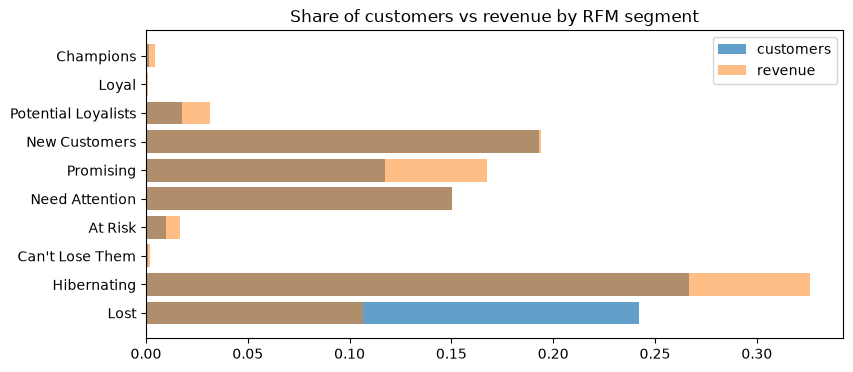

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(seg.segment, seg.share_customers, label='customers', alpha=.7)
ax.barh(seg.segment, seg.share_revenue, label='revenue', alpha=.5)
ax.invert_yaxis(); ax.legend(); ax.set_title('Share of customers vs revenue by RFM segment')
fig.savefig('../reports/figures/07_rfm_segments.png', bbox_inches='tight')

## K-Means clusters
k chosen by silhouette score on a 10k sample.

In [4]:
pd.read_parquet(P + 'cluster_k_scores.parquet').round(3)

,k,inertia,silhouette
0,3,70024.729,0.208
1,4,60930.014,0.228
2,5,53856.352,0.234
3,6,48498.019,0.207
4,7,44847.184,0.189
5,8,42067.619,0.187


In [5]:
pd.read_parquet(P + 'cluster_profile.parquet').round(2)

,cluster,cluster_name,customers,recency_days,frequency,monetary,avg_order_value,avg_items,avg_review,avg_delivery_days,late_rate,avg_installments,freight_ratio
0,0,Repeat buyers,2744,213.16,2.11,306.44,144.76,1.19,4.21,11.93,0.06,3.30,0.20
1,1,Multi-item baskets,7794,230.85,1.00,264.37,263.67,2.46,3.66,10.52,0.01,3.61,0.22
2,2,Installment shoppers,38149,232.21,1.00,236.78,236.78,1.00,4.35,11.20,0.00,3.88,0.13
3,3,Budget one-timers,37183,231.95,1.00,59.73,59.73,1.01,4.36,10.00,0.00,1.74,0.29
4,4,Unhappy (late delivery / low review),6107,212.64,1.00,174.07,174.07,1.08,2.31,33.67,1.00,3.03,0.21


## Repeat-purchase (churn) model
Train: 4 stacked cutoffs whose 180-day label windows end before the test cutoff. Test: customers as of the test cutoff. Positive class = repurchase.

In [6]:
pd.read_parquet(P + 'churn_metrics.parquet').round(4)

/var/folders/d2/brgqwp653xx3c28jywg5sqsm0000gn/T/ipykernel_7851/2291495006.py:1: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  pd.read_parquet(P + 'churn_metrics.parquet').round(4)


,model,roc_auc,pr_auc,base_rate,lift_top10,brier,selected,test_cutoff
0,logistic,0.5692,0.0224,0.0117,1.7230,0.0117,True,2018-02-20
1,lightgbm,0.5694,0.0185,0.0117,1.7713,0.0116,False,2018-02-20


In [7]:
pd.read_parquet(P + 'churn_importance.parquet').head(10)

,feature,importance
0,recency_days,0.716471
1,tenure_days,0.501165
2,avg_freight,0.295372
3,freight_ratio,0.232483
4,avg_installments,0.171479
5,cat_toys,0.164718
6,avg_order_value,0.163930
7,n_categories,0.159535
8,cat_furniture_decor,0.151072
9,monetary,0.149932


Only ~1% of customers repurchase within 180 days, so ranking signal is modest: the model roughly doubles precision over random targeting in the top decile.

## CLV by segment

In [8]:
c.groupby('segment').agg(customers=('customer_unique_id','count'), avg_clv=('clv_12m','mean'), total_clv=('clv_12m','sum'), p_repeat=('p_repeat','mean')).sort_values('avg_clv', ascending=False).round(3)

,customers,avg_clv,total_clv,p_repeat
segment,,,,
Champions,117,108.118,12649.804,0.314
Loyal,35,69.216,2422.560,0.158
Potential Loyalists,1627,35.144,57179.554,0.109
Can't Lose Them,70,19.390,1357.332,0.049
New Customers,17776,7.176,127558.339,0.018
At Risk,905,6.863,6211.088,0.020
Promising,10816,6.569,71048.828,0.012
Need Attention,13813,3.334,46050.459,0.010
Hibernating,24534,2.420,59379.792,0.006


## Category affinity (customer level)

In [9]:
pd.read_parquet(P + 'affinity_customer.parquet').head(10).round(4)

,antecedent,consequent,pair_count,support,confidence,lift
0,bed_bath_table,home_confort,53,0.0006,0.0060,1.3847
1,home_confort,bed_bath_table,53,0.0006,0.1359,1.3847
2,construction_tools_lights,furniture_decor,17,0.0002,0.0733,1.0937
3,furniture_decor,construction_tools_lights,17,0.0002,0.0028,1.0937
4,furniture_living_room,office_furniture,5,0.0001,0.0124,0.9122
5,office_furniture,furniture_living_room,5,0.0001,0.0040,0.9122
6,furniture_decor,home_construction,20,0.0002,0.0033,0.6219
7,home_construction,furniture_decor,20,0.0002,0.0417,0.6219
8,garden_tools,home_construction,10,0.0001,0.0029,0.5564
9,home_construction,garden_tools,10,0.0001,0.0208,0.5564


## State logistics performance

In [10]:
pd.read_parquet(P + 'state_performance.parquet').head(10).round(3)

,customer_state,orders,customers,revenue,avg_order_value,avg_freight,avg_delivery_days,late_rate,avg_review,revenue_share,freight_ratio
0,SP,39671,38355,5665744.58,142.818,17.371,8.352,0.045,4.244,0.372,0.122
1,RJ,12191,11767,2028416.65,166.386,23.965,14.927,0.122,3.961,0.133,0.144
2,MG,11189,10843,1796306.04,160.542,23.493,11.588,0.046,4.190,0.118,0.146
3,RS,5296,5121,853814.52,161.219,24.810,14.860,0.061,4.183,0.056,0.154
4,PR,4851,4699,773114.53,159.372,23.497,11.573,0.041,4.236,0.051,0.147
5,BA,3243,3146,589688.35,181.834,29.968,18.896,0.122,3.930,0.039,0.165
6,SC,3511,3416,587513.18,167.335,24.853,14.532,0.083,4.131,0.039,0.149
7,DF,2054,1994,341404.93,166.215,23.799,12.545,0.057,4.129,0.022,0.143
8,GO,1940,1879,331985.49,171.127,26.312,15.199,0.066,4.103,0.022,0.154
9,ES,1980,1913,312871.55,158.016,24.506,15.371,0.108,4.077,0.021,0.155
